In [1]:
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pandas as pd
import re
import numpy as np

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

# Smote
from imblearn.over_sampling import SMOTE

# IndoBERT
from transformers import pipeline

nltk.download('punkt')

# LOAD DATA
# df = pd.read_csv("dataset_komentar_500_data.csv")
df = pd.read_excel("dataset/david.xlsx")



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asust\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# NORMALISASI & STOPWORDS pada logistic regresion
dfn = pd.read_csv("preprocesing/normalisasi.csv")
normalisasi = dict(zip(dfn['slang'], dfn['formal']))

dfs = pd.read_csv("preprocesing/stopwords.csv")
stopwords = set(dfs['stopword'])


# STEMMER
factory = StemmerFactory()
stemmer = factory.create_stemmer()


# CLEANING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_comment'] = df['text'].apply(clean_text)

# PREPROCESSING
def preprocess_nb(text):
    tokens = word_tokenize(text)

    # normalisasi
    tokens = [normalisasi.get(word, word) for word in tokens]

    # stopword removal
    tokens = [word for word in tokens if word not in stopwords]

    # stemming
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)

df['tokens'] = df['clean_comment'].apply(preprocess_nb)


# Lihat hasil
print(df[['text','clean_comment','tokens']].head())

                                                text  \
0                            Baru beli poco x8 pro 😢   
1  Bang bahas Infinix GT 50 Pro bang mau keluar s...   
2                              Good Samsung i like 😊   
3  A5 series itu memang sudah terkenal HP daily u...   
4           Msh setia pake s20fe snapdragon  8/256 😂   

                                       clean_comment  \
0                               baru beli poco x pro   
1  bang bahas infinix gt pro bang mau keluar soal...   
2                                good samsung i like   
3  a series itu memang sudah terkenal hp daily us...   
4                      msh setia pake sfe snapdragon   

                                              tokens  
0                               baru beli poco x pro  
1  bang bahas infinix gt pro bang mau keluar soal...  
2                                good samsung i like  
3  a series memang sudah kenal hp daily use kompe...  
4                      msh setia pake sfe snapdrago

In [3]:
pos_df = pd.read_csv("inset_lexicon/positive.tsv", sep="\t")
neg_df = pd.read_csv("inset_lexicon/negative.tsv", sep="\t")

# gabungkan jadi 1 lexicon
lexicon = {}

for _, row in pos_df.iterrows():
    lexicon[row['word']] = row['weight']

for _, row in neg_df.iterrows():
    lexicon[row['word']] = row['weight']

In [4]:
negasi_words = {"tidak", "bukan", "nggak", "tak", "jangan"}

def labeling(text):
    words = text.split()
    score = 0

    for i, word in enumerate(words):
        prev_word = words[i-1] if i > 0 else ""

        if word in lexicon:
            weight = lexicon[word]

            if prev_word in negasi_words:
                score -= weight
            else:
                score += weight

    if score > 0:
        return "positif"
    elif score < 0:
        return "negatif"
    else:
        return "netral"

df['label'] = df['tokens'].apply(labeling)



In [5]:
# SPLIT
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(df_train['tokens'])
X_test = tfidf.transform(df_test['tokens'])

y_train = df_train['label']
y_test = df_test['label']

# K-FOLD dan SMOTE
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sm = SMOTE(random_state=42)
scores = []

for train_idx, val_idx in kf.split(X_train, y_train):

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    X_tr_resampled, y_tr_resampled = sm.fit_resample(X_tr, y_tr)

    # Gunakan data hasil resampled untuk training
    model_cv = LogisticRegression(max_iter=1000) 
   
    model_cv.fit(X_tr_resampled, y_tr_resampled)
    
    y_pred = model_cv.predict(X_val)
    scores.append(accuracy_score(y_val, y_pred))

print("Rata-rata K-Fold:", np.mean(scores))

Rata-rata K-Fold: 0.7807012602108923


In [6]:
# MODEL Logistic Regression
model_lr = model_cv.fit(X_tr_resampled, y_tr_resampled)
model_lr.fit(X_train, y_train)


# PREDICT
probs = model_lr.predict_proba(X_test)
classes = model_lr.classes_

y_pred = []

for p in probs:

    prob_neg = p[list(classes).index('negatif')]
    prob_pos = p[list(classes).index('positif')]

    if prob_neg > 0.4:
        y_pred.append('negatif')

    elif prob_pos > 0.4:
        y_pred.append('positif')

    else:
        y_pred.append('netral')

In [7]:
# prediksi Logistic Regression
print("=== Logistic Regression ===")
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Logistic Regression ===
Akurasi: 0.7622377622377622

Classification Report:
               precision    recall  f1-score   support

     negatif       0.75      0.97      0.85       438
      netral       0.73      0.41      0.53       157
     positif       0.88      0.44      0.59       120

    accuracy                           0.76       715
   macro avg       0.79      0.61      0.66       715
weighted avg       0.77      0.76      0.74       715



In [8]:
# =========================
# PREPROCESSING BERT
# =========================
def preprocess_bert(text):
    text = str(text).lower()

    # hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus HTML
    text = re.sub(r'<.*?>', '', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Terapkan preprocessing
df['clean_for_bert'] = df['text'].apply(preprocess_bert)

In [9]:
# model IndoBERT
classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
# =========================
# FUNCTION PREDIKSI
# =========================
def predict_sentiment(text):

    result = classifier(
        text,
        truncation=True,
        max_length=512
    )[0]

    label = result['label'].lower()

    # mapping label
    label_map = {
        'positive': 'positif',
        'neutral': 'netral',
        'negative': 'negatif',

        'label_0': 'negatif',
        'label_1': 'netral',
        'label_2': 'positif'
    }

    return label_map.get(label, label)


In [11]:
# HYBRID Prediksi

def hybrid_predict(text):

    # CLEANING
    clean = clean_text(text)

    # PREPROCESS LR
    processed = preprocess_nb(clean)

    # TF-IDF
    X_input = tfidf.transform([processed])

    # LR prediction
    lr_pred = model_lr.predict(X_input)[0]

    lr_prob = max(model_lr.predict_proba(X_input)[0])

    # Jika confidence rendah → pakai IndoBERT
    if lr_prob < 0.90:

        bert = classifier(
            clean,
            truncation=True,
            max_length=512
        )[0]

        label = bert['label'].lower()

        # MAPPING LABEL
        label_map = {
            'positive': 'positif',
            'negative': 'negatif',
            'neutral': 'netral',

            'label_0': 'negatif',
            'label_1': 'netral',
            'label_2': 'positif'
        }

        bert_label = label_map.get(label, label)

        return bert_label, bert['score'], "IndoBERT"

    # kalau confidence tinggi pakai LR
    return lr_pred, lr_prob, "Logistic Regression"


In [12]:
# =========================
# PREDIKSI SENTIMEN
# =========================
print("Sedang melakukan prediksi IndoBERT...")

df['pred_indobert'] = df['clean_for_bert'].apply(
    predict_sentiment
)

# HASIL

print(df[['text', 'pred_indobert']].head())

print(accuracy_score(df['label'], df['pred_indobert']))

print(classification_report(
        df['label'],
        df['pred_indobert']
    )
)

Sedang melakukan prediksi IndoBERT...
                                                text pred_indobert
0                            Baru beli poco x8 pro 😢        netral
1  Bang bahas Infinix GT 50 Pro bang mau keluar s...        netral
2                              Good Samsung i like 😊        netral
3  A5 series itu memang sudah terkenal HP daily u...       negatif
4           Msh setia pake s20fe snapdragon  8/256 😂       positif
0.51035254616676
              precision    recall  f1-score   support

     negatif       0.70      0.54      0.61      2190
      netral       0.41      0.53      0.47       786
     positif       0.25      0.37      0.30       598

    accuracy                           0.51      3574
   macro avg       0.46      0.48      0.46      3574
weighted avg       0.56      0.51      0.53      3574



In [13]:
# Menerapkan fungsi hybrid pada df_test
df_test[['hybrid_label', 'conf', 'model']] = df_test['text'].apply(
    lambda x: pd.Series(hybrid_predict(x))
)

# Menghitung metrik evaluasi
print("\n=== Hybrid Model (Logistic Regression + IndoBERT) ===")
accuracy = accuracy_score(df_test['label'], df_test['hybrid_label'])
print(f"Akurasi: {accuracy:.4f}")

# Tambahan: Melihat distribusi penggunaan model
print("\nDistribusi Penggunaan Model:")
print(df_test['model'].value_counts())


=== Hybrid Model (Logistic Regression + IndoBERT) ===
Akurasi: 0.6140

Distribusi Penggunaan Model:
model
IndoBERT               602
Logistic Regression    113
Name: count, dtype: int64


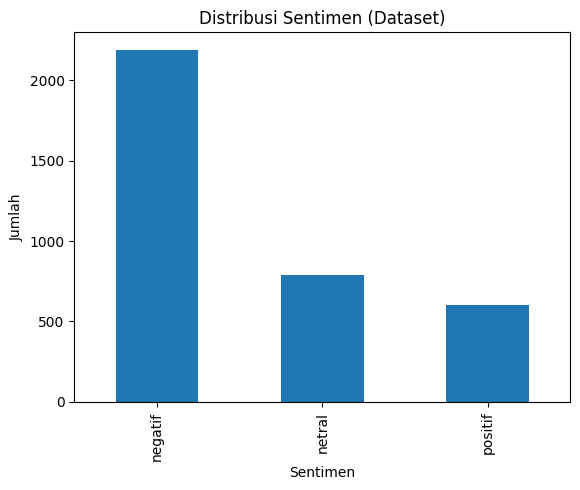

In [14]:
import matplotlib.pyplot as plt

# jumlah sentimen
sentiment_counts = df['label'].value_counts()

plt.figure()
sentiment_counts.plot(kind='bar')
plt.title("Distribusi Sentimen (Dataset)")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.show()

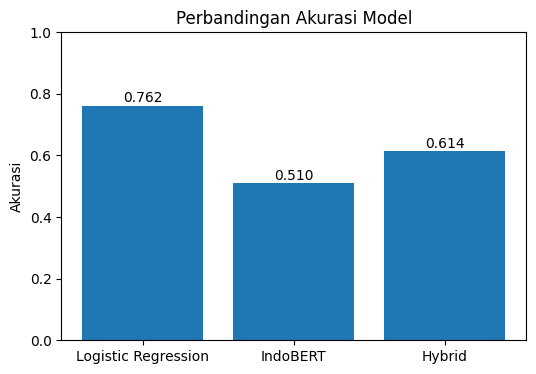

In [15]:
# AKURASI
acc_lr = accuracy_score(y_test, y_pred)
acc_bert = accuracy_score(df['label'], df['pred_indobert'])
acc_hybrid = accuracy_score(df_test['label'], df_test['hybrid_label'])

# DATA PLOT
models = ['Logistic Regression', 'IndoBERT', 'Hybrid']
scores = [acc_lr, acc_bert, acc_hybrid]

# VISUALISASI
plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.title("Perbandingan Akurasi Model")
plt.ylabel("Akurasi")
plt.ylim(0, 1)

# tampilkan nilai di atas bar
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

In [16]:
import joblib

joblib.dump(model_lr, "model_lr.pkl")
joblib.dump(tfidf, "tfidf.pkl")

print("Model berhasil disimpan")

Model berhasil disimpan
